# Pauli-Based Computation

## 1. Introduction

Any quantum circuit can be approximated to arbitrary precision using Clifford gates ($H$, $S$, $\mathrm{CNOT}$) together with the $T$ gate.

### Fault-tolerant quantum computing

In fault-tolerant quantum computing the Clifford gates can be implemented fault-tolerantly at low cost, often transversally. The $T$ gate is the exception: it has no transversal implementation. Instead we can inject a *$T$ gate* using a *Magic state*, via *$T$-state injection*. Each injection consumes one *Magic state*, which has to be prepared in advance, and is the dominant resource cost.

### The normal form

Any Clifford+$T$ circuit $U$ can be rearranged into a *Normal form* that splits it into two parts,

$$U = \Big(\prod_{i=1}^{k} R(P_i)\Big)\, C,$$

a product of *Exponents of Pauli gates* $R(P_i)$ followed by an $n$-qubit Clifford $C$.

### Pauli-based computation (PBC) framework

***Pauli-based computation (PBC)*** builds on this *Normal form*. Each exponent of a Pauli gate $R(P_i)$ is realised by using a ***Pauli product measurement*** and a ***Magic state***. The quantum hardware performs *Pauli product measurements*, while the Cliffords are handled classically. The cost is dominated by the *Magic states* that have to be prepared.

### Notebook structure

This notebook builds up the foundations of Pauli-based computation (PBC) step by step:

- **2.** Background: Pauli operators, Clifford group, and the $T$ gate
- **3.** Exponents of Pauli gates
- **4.** Normal form $U=\big(\prod_i R(P_i)\big)C$
- **5.** The Pauli-based computation (PBC) framework


## 2. Background

### 2.1 Pauli Operators

<div style="border:1px solid #d0d7de; border-left:4px solid #2a6f97;
            border-radius:6px; background:#f6f9fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#2a6f97;">Definition — Pauli operator</strong>

A ***Pauli operator*** $P$ over $n$ qubits is the tensor product of $n$ single-qubit Pauli matrices $P_i$ drawn from $\{I, X, Y, Z\}$:

$$P := P_1 \otimes P_2 \otimes \cdots \otimes P_n, \quad P_i \in \{I, X, Y, Z\}.$$

We write $\mathcal{P}_n$ for the set of all Pauli operators on $n$ qubits.

</div>

<div style="border:1px solid #d6cce6; border-left:4px solid #6a4c93;
            border-radius:6px; background:#f8f6fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6a4c93;">Property — Hermitian and squares to the identity</strong>

Every Pauli operator satisfies

$$P^\dagger = P \qquad\text{and}\qquad P^2 = I.$$

Its eigenvalues lie in $\{+1, -1\}$.

</div>

#### 2.1.1 Symplectic representation

Since $Y = iXZ$, we can represent $P$ with two bitvectors $x = (x_1 \ldots x_n)$ and $z = (z_1 \ldots z_n)$:

$$P(x, z) = i^{\langle x, z \rangle}\, X^x Z^z = P_1 \otimes P_2 \otimes \cdots \otimes P_n,$$

where the phase $i^{\langle x, z \rangle}$ (one factor of $i$ per $Y$) makes $P$ Hermitian, and each single-qubit factor $P_i$ is determined by:

| $x_i$ | $z_i$ | $P_i$ |
|--------|--------|--------|
| 0      | 0      | $I$    |
| 1      | 0      | $X$    |
| 1      | 1      | $Y$    |
| 0      | 1      | $Z$    |

For example, $P = X \otimes Y \otimes Z$ has $x = (1,1,0)$ and $z = (0,1,1)$, since:

$$\begin{align*}
P(x,z) &= i^{\langle (1,1,0),\,(0,1,1) \rangle} \, X^{(1,1,0)} Z^{(0,1,1)} \\
        &= i^1 \cdot (X \otimes X \otimes I)(I \otimes Z \otimes Z) \\
        &= X \otimes iXZ \otimes Z \\
        &= X \otimes Y \otimes Z
\end{align*}$$

> Instead of storing a Pauli operator over $n$ qubits as $n$ separate $2 \times 2$ matrices, in practice only the two length-$n$ bitvectors $x$ and $z$ are stored.


### 2.2 Pauli product measurements 
<a id="sec-ppm"></a>

<div style="border:1px solid #d0d7de; border-left:4px solid #6c757d;
            border-radius:6px; background:#f7f8f9; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6c757d;">Recall — projection postulate</strong>

A projective measurement is specified by a set of orthogonal projectors $\{\Pi_i\}$ with $\sum_i \Pi_i = I$ and $\Pi_i \Pi_j = \delta_{ij}\,\Pi_i$.

For a system in state $|\psi\rangle$, outcome $i$ occurs with probability $p_i = \langle\psi|\Pi_i|\psi\rangle$, and the state is updated to $\Pi_i|\psi\rangle/\sqrt{p_i}$.

</div>

<div style="border:1px solid #d0d7de; border-left:4px solid #2a6f97;
            border-radius:6px; background:#f6f9fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#2a6f97;">Definition — Pauli product measurement</strong>

A ***Pauli product measurement*** measures a Pauli operator $M \in \mathcal{P}_n \setminus \{I\}$ as an observable. Since $M$ is Hermitian with $M^2 = I$, its eigenvalues are $\pm 1$, we can create orthogonal projectors

$$
\begin{aligned}
&\Pi_\pm = \tfrac{1}{2}\bigl(I \pm M\bigr), \\
&\Pi_+ + \Pi_- = I, \qquad \Pi_+\Pi_- = 0, \qquad \Pi_\pm^2 = \Pi_\pm.
\end{aligned}
$$


Applied to a state $|\psi\rangle$, the measurement returns a **single bit** $m$ encoding the eigenvalue $(-1)^m$, and projects onto the corresponding eigenspace related to this eigenvalue,

$$|\psi'\rangle = \frac{\Pi_{(-1)^m}\,|\psi\rangle}{\sqrt{p}}, \qquad
p = \langle\psi|\Pi_{(-1)^m}|\psi\rangle .$$

</div>

<div style="border:1px solid #f5d6a8; border-left:4px solid #e67e22;
            border-radius:6px; background:#fdf6ec; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#e67e22;">❗ Important</strong>

This is a **non-demolition** measurement: for a Pauli product measurement on $n \ge 2$ qubits, each $\Pi_\pm$ projects onto a whole eigenspace (of dimension $2^{\,n-1}$), not onto a single basis state. No individual qubit is read out, only the $\pm 1$ outcome.

</div>

### 2.2.1 Example: *Pauli product measurement* of $Z\otimes Z$ on $|{+}{+}\rangle$

As a simple example, we measure $Z\otimes Z$ on the product state $|{+}{+}\rangle$.

<img src="assets/pauli_product_measurement_ex1.png" width="200">

<div style="border:1px solid #bcd9c5; border-left:4px solid #2d6a4f;
            border-radius:6px; background:#f4faf6; padding:0.8em 1.2em; margin:1em 0;">

$$Z\otimes Z=\begin{pmatrix}1&0&0&0\\0&-1&0&0\\0&0&-1&0\\0&0&0&1\end{pmatrix}$$

is diagonal, with eigenvalues $+1,-1,-1,+1$ on the basis states $|00\rangle,|01\rangle,|10\rangle,|11\rangle$. So the $+1$ eigenspace is spanned by $\{|00\rangle,|11\rangle\}$ and the $-1$ eigenspace by $\{|01\rangle,|10\rangle\}$.

We measure the **product** state

$$|{+}{+}\rangle = \tfrac12\bigl(|00\rangle+|01\rangle+|10\rangle+|11\rangle\bigr).$$

Applying $Z\otimes Z$ (multiply each basis state by its eigenvalue) and projecting with $\Pi_+ = \tfrac12(I + Z\otimes Z)$:

$$
Z\otimes Z\,|{+}{+}\rangle = \tfrac12\bigl(|00\rangle-|01\rangle-|10\rangle+|11\rangle\bigr),
\qquad
\Pi_+|{+}{+}\rangle = \tfrac12\bigl(|00\rangle+|11\rangle\bigr),
$$

with probability $p_+ = \bigl\|\tfrac12(|00\rangle+|11\rangle)\bigr\|^2 = \tfrac12$. Normalising (and the same with $\Pi_- = \tfrac12(I - Z\otimes Z)$) gives the two outcomes:

$$
+1:\ \tfrac{1}{\sqrt2}\bigl(|00\rangle+|11\rangle\bigr) = |\Phi^+\rangle,
\qquad
-1:\ \tfrac{1}{\sqrt2}\bigl(|01\rangle+|10\rangle\bigr) = |\Psi^+\rangle,
$$

each with probability $\tfrac12$. Both are **Bell states**.

<img src="assets/pauli_product_measurement_ex2.png" width="300">

**So this *Pauli product measurement* turned a product state into an *entangled* one.**

</div>


The following code verifies this using `PauliProductMeasurement` from Qiskit: we prepare $|{+}{+}\rangle$, apply the Pauli product measurement $Z\otimes Z$, and sample the outcome $m$ (whose
eigenvalue is $(-1)^m$).
The two outcomes appear with probability $\approx\tfrac12$.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliProductMeasurement
from qiskit.quantum_info import Pauli
from qiskit_aer import AerSimulator

qc = QuantumCircuit(2, 1)

# State |++> preparation
qc.h([0, 1])

# Pauli product measurement: Z⊗Z
qc.append(PauliProductMeasurement(Pauli("ZZ")), [0, 1], [0])

# sample the outcome m; the measured eigenvalue is (-1)^m
sim = AerSimulator(seed_simulator=42)
counts = sim.run(qc.decompose(), shots=4000).result().get_counts()

shots = sum(counts.values())
for m in sorted(counts):
    print(
        f"m={m}  (eigenvalue {(-1)**int(m):+d}):  {counts[m]:>4}  ({counts[m]/shots:.1%})"
    )

m=0  (eigenvalue +1):  2003  (50.1%)
m=1  (eigenvalue -1):  1997  (49.9%)


### 2.3 The Clifford Group

<div style="border:1px solid #d0d7de; border-left:4px solid #2a6f97;
            border-radius:6px; background:#f6f9fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#2a6f97;">Definition — Clifford group</strong>

The ***Clifford group*** $\mathcal{C}_n$ over $n$ qubits is the set of unitaries that map every Pauli operator to a Pauli operator under conjugation:

$$\mathcal{C}_n := \{\, U \in U(2^n) \mid U P U^\dagger \in \mathcal{P}_n \;\;\forall P \in \mathcal{P}_n \,\},$$

where $\mathcal{P}_n$ is the Pauli group defined above.

</div>



#### 2.3.1 Generators

Up to a global phase, the $n$-qubit Clifford group is generated by Hadamard $H$, phase $S$, and CNOT gates applied to individual qubits or pairs of qubits:

$$\mathcal{C}_n = \langle H_i, S_i, \text{CNOT}_{i,j} \rangle,$$

where $H_i$ denotes $H$ acting on qubit $i$ and the identity on all other qubits (and analogously for $S_i$ and $\text{CNOT}_{i,j}$, where $i$ is the control qubit and $j$ is the target qubit).

In the computational basis we have:

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \quad 
S = \begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}.$$

The Hadamard gate is self-inverse ($H^\dagger = H$), while the phase gate is not:

$$H^{\dagger} = H, \quad S^{\dagger} = \begin{pmatrix} 1 & 0 \\ 0 & -i \end{pmatrix}.$$

The CNOT gate acts on two qubits, designating one as the control and the other as the target. When the control is in state $|1\rangle$, the gate applies $X$ to the target, where $X$ is the bit-flip (NOT) operation that maps $|0\rangle \leftrightarrow |1\rangle$. In the basis $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$ with the first qubit as control:

$$\text{CNOT} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}.$$

We write $\text{CNOT}_{i,j}$ for this gate placed with control on qubit $i$ and target on qubit $j$, acting as identity on all other qubits.



**Action on Pauli Operators**

By definition, a Clifford maps $\mathcal{P}_n \to \mathcal{P}_n$; the tables below illustrate how the conjugation of $H$, $S$ and $\text{CNOT}$ acts on the Pauli operators

For single-qubit gates, these rules follow from direct matrix multiplication (e.g., $H X H = Z$).

<a id="pauli-conjugation"></a>

<img src="assets/pauli_conjugation_hs.png" width="800">


The action of $\text{CNOT}_{i,j}$ on single-Pauli inputs under conjugation is given by $P \mapsto \text{CNOT}_{i,j}\, P\, \text{CNOT}_{i,j}^\dagger$ which is equal to $P \mapsto \text{CNOT}_{i,j}\, P\, \text{CNOT}_{i,j}$ since $CNOT$ is self-inverse.

<img src="assets/pauli_conjugation_cnot.png" width="800">



### 2.3.2 Properties

<div style="border:1px solid #d6cce6; border-left:4px solid #6a4c93;
            border-radius:6px; background:#f8f6fc; padding:0.8em 1.2em; margin:1em 0;">

<a id="sec-clifford-ft"></a>

<strong style="color:#6a4c93;">Fault tolerant benefit: applied transversally</strong>

The Clifford gates are inexpensive to protect against errors: in error correcting codes
such as the Steane code ([Steane, 1996](https://arxiv.org/abs/quant-ph/9601029)) they can
be applied *transversally* (acting on each physical qubit separately, which does not
spread errors).

</div>


<div style="border:1px solid #d6cce6; border-left:4px solid #6a4c93;
            border-radius:6px; background:#f8f6fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6a4c93;">Is not universal</strong>

But the Clifford group has only finitely many elements, so it can't approximate *every* unitary in $U(2^n)$. This ability for the so called *universality* is what general quantum computation requires, and adding a single non-Clifford gate, the $T$ gate (next section), achieves it.

</div>

### 2.4 T gate

The non-Clifford gate that completes the Clifford gates to a universal set is the
***$T$ gate***.

<div style="border:1px solid #d0d7de; border-left:4px solid #2a6f97;
            border-radius:6px; background:#f6f9fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#2a6f97;">Definition — T gate</strong>

The ***$T$ gate*** is the single-qubit phase gate

$$T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}, \qquad T^2 = S,$$

i.e. it applies a phase of $e^{i\pi/4}$ to $|1\rangle$ and leaves $|0\rangle$ unchanged.

</div>

<div style="border:1px solid #e6d77a; border-left:4px solid #c9a227;
            border-radius:6px; background:#fdfae6; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#a07c00;">Key fact — Clifford+T is universal</strong>

Adding $T$ to the Clifford gates yields the universal gate set $\{H, T, \mathrm{CNOT}\}$. The Clifford gates alone are not universal, but together with $T$ they generate a **dense** subset of $U(2^n)$, so any unitary can be approximated to arbitrary precision.

</div>


<div style="border:1px solid #d6cce6; border-left:4px solid #6a4c93;
            border-radius:6px; background:#f8f6fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6a4c93;">Property — T escapes the Pauli group</strong>

Conjugating a Pauli by a Clifford gate gives another Pauli. Conjugating by $T$ does
**not**:

$$T X T^\dagger = \tfrac{1}{\sqrt{2}}(X + Y) \notin \mathcal{P}_1 .$$

So Clifford gates keep the description *inside* the Pauli group $\mathcal{P}_n$, where
it stays efficiently trackable, while each $T$ gate maps it *outside*, which is used to construct a universal gate set.

</div>

#### Why T gate is "expensive"

<div style="border:1px solid #f5d6a8; border-left:4px solid #e67e22;
            border-radius:6px; background:#fdf6ec; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#e67e22;">❗ Important</strong>

Unlike the Clifford gates, $T$ cannot be implemented *transversally* in a fault-tolerant
code, so it cannot be applied directly to logical qubits. Instead it is realised by
*$T$-state injection* using a *Magic state* (as we will see later). This *Magic state* preparation makes it computationally costly.

</div>


## 3 Exponents of Pauli Gates


Now we look deeper of the form of the T gate

$T$ gate can be expressed as an exponent. We can write the $T$ gate as following

$T = e^{\,i\frac{\pi}{8}(I - Z)} = \tfrac{1}{2}\big(1 + e^{i\pi/4}\big)I + \tfrac{1}{2}\big(1 - e^{i\pi/4}\big)Z,$

This is a $\tfrac{\pi}{4}$ rotation about the $Z$ axis.

<img src="assets/bloch_t_rotation.png" width="400">


Replacing $Z$ by another single-qubit Pauli gives the same gate seen along a different axis, each a $\tfrac{\pi}{4}$ rotation up to a global phase:

$R(X) = e^{\,i\frac{\pi}{8}(I - X)} = H\,{\color{red}T}\,H \qquad (\tfrac{\pi}{4}\text{ rotation about the } X \text{ axis}),$

$R(Y) = e^{\,i\frac{\pi}{8}(I - Y)} = S\,H\,{\color{red}T}\,H\,S^\dagger \qquad (\tfrac{\pi}{4}\text{ rotation about the } Y \text{ axis}),$

$R(Z) = e^{\,i\frac{\pi}{8}(I - Z)} = {\color{red}T} \qquad (\tfrac{\pi}{4}\text{ rotation about the } Z \text{ axis}).$

We see that each can be expressed with only one ${\color{red}T}$.



We looked at the rotation on one qubit if we extend on $n$-qubit space we obtain the so-called ***exponent of a Pauli gate***

<div style="border:1px solid #d0d7de; border-left:4px solid #2a6f97;
            border-radius:6px; background:#f6f9fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#2a6f97;">Definition — Exponent of a Pauli gate</strong>

For $P \in \mathcal{P}_n \setminus \{I_{2^n}\}$, the ***exponent of a Pauli gate*** about
$\pm P$ is

$$R(\pm P) := e^{\,i\frac{\pi}{8}(I \mp P)}
   = \tfrac{1}{2}\big(1 + e^{i\pi/4}\big)I_{2^n} \pm \tfrac{1}{2}\big(1 - e^{i\pi/4}\big)P .$$

These are $\tfrac{\pi}{4}$ rotations around $P$, up to a global phase.

</div>



**Cliffords map rotations to rotations.** For any Clifford $C \in \mathcal{C}_n$,

$$C\, R(P)\, C^\dagger = R\big(C P C^\dagger\big).$$

Conjugating an exponent of a Pauli gate by a Clifford gives another exponent of a Pauli gate, with axis the conjugated Pauli $C P C^\dagger$. Because conjugation stays inside the Pauli operators, the right-hand side is again a valid rotation. 


<a id="push-cliffords-right"></a>

<div style="border:1px solid #d6cce6; border-left:4px solid #6a4c93;
            border-radius:6px; background:#f8f6fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6a4c93;">Consequence — push Cliffords to the right</strong>

This identity implies

$$\textcolor{green}{\mathbf{C}}\, R(P) = R\big(C P C^\dagger\big)\, \textcolor{green}{\mathbf{C}} = R(P')\, \textcolor{green}{\mathbf{C}}, \qquad \text{where } P' = C P C^\dagger \in \mathcal{P}_n.$$

which means we can move a Clifford $\textcolor{green}{\mathbf{C}}$ **to the right** past a rotation by conjugating its
Pauli. Repeating this collects every Clifford on the right. This is the basis of the **normal
form** in the next section.

</div>


## 4 Normal Form for Clifford+T Circuits

### 4.1 Statement and Meaning
<div style="border:1px solid #cfd3ec; border-left:4px solid #3b3f8c;
            border-radius:6px; background:#f5f6fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#3b3f8c;">Theorem — Normal form</strong>

Let $U$ be a $2^n \times 2^n$ unitary that can be represented by a Clifford+$T$ circuit
($\{H, S, \mathrm{CNOT}, T\}$). Then there exist $P_1, P_2, \ldots, P_k \in \mathcal{P}_n$
and $C \in \mathcal{C}_n$ such that

$$U = \left(\prod_{i=1}^{k} R(P_i)\right) \cdot C.$$

This normal form partitions the circuit into two parts:

1. the first part, $\prod_{i=1}^{k} R(P_i)$, consists only of exponents of Pauli gates;
2. the second part, $C$, is a single Clifford operation.

</div>





### 4.2 Proof

Suppose $U$ is given as a Clifford+$T$ circuit with exactly $k$ $T$ gates. The Clifford
gates between (and around) the $T$ gates group into Clifford operators
$C_1, C_2, \ldots, C_{k+1}$ (some possibly the identity), so the circuit reads

$$U = C_1\, R(P_1)\, C_2\, R(P_2)\cdots C_k\, R(P_k)\, C_{k+1}.$$

Now we apply ["Push Cliffords to the right"](#push-cliffords-right) repeatedly: each
$R(P_i)$ is replaced by $R(P_i')$ with a conjugated Pauli $P_i' \in \mathcal{P}_n$, and
all the Clifford factors collect into a single Clifford at the end,
$C = C_1 C_2 \cdots C_{k+1} \in \mathcal{C}_n.$

This yields $U = \left(\prod_{i=1}^{k} R(P_i')\right) C. \qquad\blacksquare$


### 4.3 Algorithm (applied example)
The following graphics in [Action on Pauli operators](#pauli-conjugation) can help to understand the calculation steps.



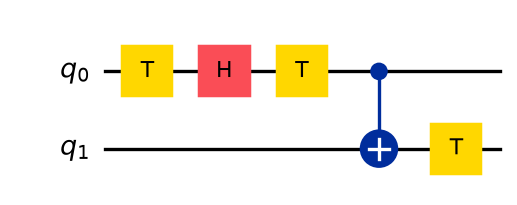

<IPython.core.display.Math object>

In [ ]:
from viz import normal_form_steps_to_latex, draw_circuit
from IPython.display import display

u = [("T", [0]), ("H", [0]), ("T", [0]), ("CNOT", [0, 1]), ("T", [1])]
display(draw_circuit(u, 2))
display(normal_form_steps_to_latex(u, 2))

## 5. Framework: Pauli based Computation

The *normal form* factors any Clifford+$T$ unitary into exponents of Pauli gates followed
by a single Clifford,

$$U = \Big(\prod_i R(P_i)\Big)\, C.$$

The Clifford $C$ is the easy part. Clifford gates can be applied *transversally* and are
therefore cheap to make fault tolerant (see
[Fault tolerant benefit: applied transversally](#sec-clifford-ft)). The cost sits entirely
in the exponents $R(P_i)$.

Take $P_i = Z$: then $R(Z) = T$, and the $T$ gate has **no transversal implementation**, so it cannot be applied directly to a logical qubit.

<img src="assets/t_gate_not_direct.png" width="200">


We first look, in isolation, at how to apply a single $T$ gate *without* applying it directly. For this we turn to *Magic states*.

### 5.1 Magic state

<div style="border:1px solid #d0d7de; border-left:4px solid #2a6f97;
            border-radius:6px; background:#f6f9fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#2a6f97;">Definition — Magic state</strong>

A *Magic state* is the fixed single-qubit state

$$|T\rangle = T|+\rangle = \tfrac{1}{\sqrt{2}}\bigl(|0\rangle + e^{i\pi/4}|1\rangle\bigr).$$

</div>

*Magic states* are produced in dedicated hardware regions called *factories*. A factory uses only Clifford operations to distil many noisy copies into a few very accurate ones, so a *Magic state* can be made as precise as needed without ever applying a $T$ gate ([Bravyi & Kitaev, 2005](https://arxiv.org/abs/quant-ph/0403025)). This is why we may treat them as ideal here. But producing them is **expensive**: Magic state distillation dominates the cost of fault-tolerant computation, so the number of *Magic states* consumed is the key resource.


### $T$-state injection (applying a $T$ gate without using a $T$ gate)

The circuit below shows how to produce $T|\psi\rangle$ without applying $T$ directly.

<img src="assets/t_state_injection.png" width="700">

It uses only a *Magic state*, a CNOT, a measurement, and a Clifford correction, which are all Clifford. We now go through the calculation step by step



#### Calculation steps


<div style="background:#0b7285; color:#fff; padding:4px 12px; border-radius:4px; font-weight:bold; display:inline-block; margin:.2em 0 .6em;">Step — |Ψ₀⟩ : initial state</div>

The data qubit is generally $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$, and the *Magic state* is $|T\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle + e^{i\pi/4}|1\rangle)$:

$$
\begin{aligned}
|\Psi_0\rangle
&= |\psi\rangle \otimes |T\rangle
 = \bigl(\alpha|0\rangle + \beta|1\rangle\bigr) \otimes \tfrac{1}{\sqrt{2}}\bigl(|0\rangle + e^{i\pi/4}|1\rangle\bigr) \\
&= \tfrac{1}{\sqrt{2}}\Bigl( \alpha|0\rangle\bigl(|0\rangle + e^{i\pi/4}|1\rangle\bigr)
   + \beta|1\rangle\bigl(|0\rangle + e^{i\pi/4}|1\rangle\bigr) \Bigr).
\end{aligned}
$$

<div style="background:#0b7285; color:#fff; padding:4px 12px; border-radius:4px; font-weight:bold; display:inline-block; margin:.2em 0 .6em;">Step — |Ψ₁⟩ : CNOT</div>

Apply a CNOT with $|\psi\rangle$ as control and $|T\rangle$ as target:

$$
\begin{aligned}
|\Psi_1\rangle
&= \mathrm{CNOT}\,\bigl(|\psi\rangle \otimes |T\rangle\bigr) \\
&= \tfrac{1}{\sqrt{2}}\Bigl( \alpha|0\rangle\bigl(|0\rangle + e^{i\pi/4}|1\rangle\bigr)
   + \beta|1\rangle\bigl(|1\rangle + e^{i\pi/4}|0\rangle\bigr) \Bigr) \\
&= \tfrac{1}{\sqrt{2}}\Bigl( \bigl(\alpha|0\rangle + \beta e^{i\pi/4}|1\rangle\bigr)|0\rangle
   + \bigl(\alpha e^{i\pi/4}|0\rangle + \beta|1\rangle\bigr)|1\rangle \Bigr).
\end{aligned}
$$

<div style="background:#0b7285; color:#fff; padding:4px 12px; border-radius:4px; font-weight:bold; display:inline-block; margin:.2em 0 .6em;">Step — |Ψ₂⟩ : measure and correct</div>

We measure the *Magic state* and save the outcome in $m$. Afterwards simply discard the state (equivalently, reset it to $|0\rangle$).

**Case $m = 0$:** no correction, so directly

$$
|\Psi_2\rangle = \bigl(\alpha|0\rangle + \beta e^{i\pi/4}|1\rangle\bigr)\,|0\rangle = T|\psi\rangle \otimes |0\rangle.
$$

**Case $m = 1$:** apply the Clifford correction $S = \mathrm{diag}(1, i)$:

$$
\begin{aligned}
|\Psi_2\rangle
&= S\bigl(\alpha e^{i\pi/4}|0\rangle + \beta|1\rangle\bigr) \otimes |0\rangle
 = \bigl(\alpha e^{i\pi/4}|0\rangle + \beta\, i\,|1\rangle\bigr) \otimes |0\rangle \\
&= e^{i\pi/4}\bigl(\alpha|0\rangle + \beta e^{i\pi/4}|1\rangle\bigr) \otimes |0\rangle
 = e^{i\pi/4}\,T|\psi\rangle \otimes |0\rangle.
\end{aligned}
$$

So $|\Psi_2\rangle = T|\psi\rangle \otimes |0\rangle$ in both cases (up to a global phase). The $T$-state injection is realised with only Clifford gates.

### 5.2 Generalisation to $R(P)$

We now look at how to apply the methods discussed before to obtain $R(P_i)|\psi\rangle$ without applying $R(P_i)$ directly, since $R(P_i)$ is not a Clifford operator,

$$R(P) = \exp\!\left[\,i\tfrac{\pi}{8}\,(I - P)\right] \notin \mathcal{C}_n .$$

The following image shows how this is done:

<img src="assets/pbc_framework.png" width="900">

The circuit applies $R(P)$ using only a *Pauli product measurement* of $P\otimes Z$, a *Magic state* and an $X$-measurement of it, and two Clifford corrections.

We first set up the two operations it relies on (the Clifford corrections and the *Pauli product measurement*), then go through the calculation step by step.

<div style="border:1px solid #d6cce6; border-left:4px solid #6a4c93;
            border-radius:6px; background:#f8f6fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6a4c93;">Clifford corrections</strong>

The algorithm uses two outcome-controlled corrections, both Clifford:

$$\textcolor{purple}{S(P)} := R(P)^2 = \exp\!\left[\,i\tfrac{\pi}{4}(I-P)\right] \in \mathcal{C}_n, \qquad \textcolor{teal}{P} \in \mathcal{P}_n \subset \mathcal{C}_n .$$

$S(P)$ is Clifford because squaring doubles the rotation angle from $\pi/4$ to $\pi/2$,
and a $\pi/2$ rotation about a Pauli is Clifford. For a single qubit this is just the
phase gate: *$S(Z)=R(Z)^2=T^2=S$*, which also explains the name $S(P)$. 

The Pauli correction $P$ is Clifford too, since every Pauli is itself a Clifford.


</div>


<div style="border:1px solid #d0d7de; border-left:4px solid #6c757d;
            border-radius:6px; background:#f7f8f9; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6c757d;">Recall — Pauli product measurement (<a href="#sec-ppm">2.2</a>)</strong>

We also use a *Pauli product measurement* of $M = P\otimes Z$ , where $P$ acts on the $n$ data qubits of $|\psi\rangle$ and $Z$ on the *Magic state* . Here $M = P\otimes Z \in \mathcal{P}_n\setminus\{I\}$, with orthogonal projectors

$$\Pi_\pm = \tfrac12\bigl(I \pm M\bigr) = \tfrac12\bigl(I \pm P\otimes Z\bigr).$$

</div>

<a id="rp-eigenbasis"></a>
<div style="border:1px solid #d6cce6; border-left:4px solid #6a4c93;
            border-radius:6px; background:#f8f6fc; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#6a4c93;">Everything is diagonal in the Eigenbasis</strong>

Since $P$ acts only on $|\psi\rangle$, split it into the $\pm1$ eigenspaces of $P$:

$$|\psi\rangle = |\psi_+\rangle + |\psi_-\rangle, \qquad |\psi_\pm\rangle = \tfrac12(I \pm P)\,|\psi\rangle, \qquad P|\psi_\pm\rangle = \pm|\psi_\pm\rangle .$$

Since each $|\psi_\pm\rangle$ is an eigenstate of $P$, it is also an eigenstate of $S(P)$ and $R(P)$:

$$\begin{array}{c|c|c|c} & P & S(P) & R(P) \\ \hline |\psi_+\rangle & +|\psi_+\rangle & |\psi_+\rangle & |\psi_+\rangle \\ |\psi_-\rangle & -|\psi_-\rangle & i\,|\psi_-\rangle & e^{i\pi/4}|\psi_-\rangle \end{array}$$

</div>

<div style="border:1px solid #e6d77a; border-left:4px solid #c9a227;
            border-radius:6px; background:#fdfae6; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#a07c00;">Goal</strong>

The state we want to reach is

$$R(P)\,|\psi\rangle = |\psi_+\rangle + e^{i\pi/4}|\psi_-\rangle .$$

</div>



#### Calculation steps

<div style="background:#0b7285; color:#fff; padding:4px 12px; border-radius:4px; font-weight:bold; display:inline-block; margin:.2em 0 .6em;">Step — |Ψ₀⟩ : initial state</div>

Initial setup: $|\Psi_0\rangle$
$|\psi\rangle$ is in this case a $n$-qubit state. And we use a *Magic state* $|T\rangle$

So we have 
$$\begin{aligned}
|\Psi_0\rangle
&= |\psi\rangle \otimes |T\rangle \\
&= \bigl(|\psi_+\rangle + |\psi_-\rangle\bigr) \otimes \tfrac{1}{\sqrt{2}}\bigl(|0\rangle + e^{i\pi/4}|1\rangle\bigr) \\
&= \tfrac{1}{\sqrt{2}}\Bigl( |\psi_+\rangle|0\rangle + e^{i\pi/4}|\psi_+\rangle|1\rangle
   + |\psi_-\rangle|0\rangle + e^{i\pi/4}|\psi_-\rangle|1\rangle \Bigr).
\end{aligned}
$$


<div style="background:#0b7285; color:#fff; padding:4px 12px; border-radius:4px; font-weight:bold; display:inline-block; margin:.2em 0 .6em;">Step — |Ψ₁⟩ : Pauli product measurement</div>

As discussed before, we use a *Pauli product measurement* of $P \otimes Z$. It returns a single bit $m_1$ encoding the eigenvalue $(-1)^{m_1}$. Both outcomes occur with probability $\tfrac12$, independent of $|\psi\rangle$:

$$
\begin{aligned}
p_\pm = \langle \Psi_0 |\, \Pi_\pm \,|\Psi_0\rangle
&= \tfrac{1}{2}\Bigl(\langle\Psi_0|\Psi_0\rangle \pm \langle\Psi_0|\,P\otimes Z\,|\Psi_0\rangle\Bigr) \\
&= \tfrac{1}{2}\Bigl(1 \pm \langle\psi|P|\psi\rangle\,\langle T|Z|T\rangle\Bigr)
 = \tfrac{1}{2},
\end{aligned}
$$

where we used $\langle T|Z|T\rangle = 0$:

$$
\langle T|Z|T\rangle
= \tfrac{1}{2}\bigl(\langle 0| + e^{-i\pi/4}\langle 1|\bigr)\bigl(|0\rangle - e^{i\pi/4}|1\rangle\bigr)
= \tfrac{1}{2}\bigl(1 - 1\bigr) = 0.
$$

*$m_1$ values*:

- case $0$ (eigenvalue $+1$, $\Pi_+ = \tfrac12(I + P\otimes Z)$ keeps the $+1$ terms $|\psi_+\rangle|0\rangle$, $|\psi_-\rangle|1\rangle$):
$$
|\Psi_1\rangle = \frac{\Pi_+\,|\Psi_0\rangle}{\sqrt{p_+}}
= \sqrt{2}\cdot \tfrac{1}{\sqrt{2}}\bigl(|\psi_+\rangle|0\rangle + e^{i\pi/4}|\psi_-\rangle|1\rangle\bigr)
= |\psi_+\rangle|0\rangle + e^{i\pi/4}|\psi_-\rangle|1\rangle.
$$

- case $1$ (eigenvalue $-1$, $\Pi_- = \tfrac12(I - P\otimes Z)$ keeps the $-1$ terms $|\psi_+\rangle|1\rangle$, $|\psi_-\rangle|0\rangle$):
$$
|\Psi_1\rangle = \frac{\Pi_-\,|\Psi_0\rangle}{\sqrt{p_-}}
= \sqrt{2}\cdot \tfrac{1}{\sqrt{2}}\bigl(e^{i\pi/4}|\psi_+\rangle|1\rangle + |\psi_-\rangle|0\rangle\bigr)
= e^{i\pi/4}|\psi_+\rangle|1\rangle + |\psi_-\rangle|0\rangle.
$$

Therefore for $|\Psi_1\rangle$:

$$
\begin{array}{c|c}
 & |\Psi_1\rangle \\
\hline
m_1 = 0 & |\psi_+\rangle|0\rangle + e^{i\pi/4}|\psi_-\rangle|1\rangle \\[4pt]
m_1 = 1 & e^{i\pi/4}|\psi_+\rangle|1\rangle + |\psi_-\rangle|0\rangle
\end{array}
$$


<div style="background:#0b7285; color:#fff; padding:4px 12px; border-radius:4px; font-weight:bold; display:inline-block; margin:.2em 0 .6em;">Step — |Ψ₂⟩ : X-readout of the Magic state</div>

We measure the *Magic state* in the $X$ basis: in practice we first apply $H$ and then measure in the $Z$ basis, which projects the qubit onto the $X$ eigenbasis $\{|+\rangle, |-\rangle\}$. We save the outcome in $m_2$, encoding the eigenvalue $(-1)^{m_2}$. Afterwards the *Magic state* is disentangled from the data, so we discard it (equivalently, reset it to $|0\rangle$).

<div style="border:1px solid #f5d6a8; border-left:4px solid #e67e22;
            border-radius:6px; background:#fdf6ec; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#e67e22;">❗ Attention: why X measurement</strong>

A $Z$ measurement would instead collapse the data $|\psi\rangle$ onto a single eigenstate $|\psi_+\rangle$ or $|\psi_-\rangle$ of $P$. It would *measure* $P$ on the data and destroy the rotation, rather than *apply* $R(P)$.

</div>

The bit $m_2$ tells which state the qubit is projected onto:

- $m_2 = 0$: eigenvalue $(-1)^0 = +1$, projected onto $|+\rangle = \tfrac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr)$.
- $m_2 = 1$: eigenvalue $(-1)^1 = -1$, projected onto $|-\rangle = \tfrac{1}{\sqrt{2}}\bigl(|0\rangle - |1\rangle\bigr)$.

**For $m_1 = 0$**, with $|\Psi_1\rangle = |\psi_+\rangle|0\rangle + e^{i\pi/4}|\psi_-\rangle|1\rangle$:

$$
\langle\pm|\Psi_1\rangle
= |\psi_+\rangle\,\langle\pm|0\rangle + e^{i\pi/4}|\psi_-\rangle\,\langle\pm|1\rangle
= \tfrac{1}{\sqrt2}\bigl(|\psi_+\rangle \pm e^{i\pi/4}|\psi_-\rangle\bigr),
$$

so after normalising and resetting:

$$
|\Psi_2\rangle = \bigl(|\psi_+\rangle \pm e^{i\pi/4}|\psi_-\rangle\bigr)\otimes|0\rangle .
$$

**For $m_1 = 1$**, with $|\Psi_1\rangle = e^{i\pi/4}|\psi_+\rangle|1\rangle + |\psi_-\rangle|0\rangle$:

$$
\langle\pm|\Psi_1\rangle
= e^{i\pi/4}|\psi_+\rangle\,\langle\pm|1\rangle + |\psi_-\rangle\,\langle\pm|0\rangle
= \tfrac{1}{\sqrt2}\bigl(\pm e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr),
$$

so after normalising and resetting:

$$
|\Psi_2\rangle = \bigl(\pm e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr)\otimes|0\rangle .
$$

The table collects the four outcomes for $|\Psi_2\rangle$:

$$
\begin{array}{c|cc}
 & m_2 = 0 & m_2 = 1 \\
\hline
m_1 = 0 & \bigl(|\psi_+\rangle + e^{i\pi/4}|\psi_-\rangle\bigr)\otimes|0\rangle
        & \bigl(|\psi_+\rangle - e^{i\pi/4}|\psi_-\rangle\bigr)\otimes|0\rangle \\[4pt]
m_1 = 1 & \bigl(e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr)\otimes|0\rangle
        & \bigl(-e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr)\otimes|0\rangle
\end{array}
$$


<div style="background:#0b7285; color:#fff; padding:4px 12px; border-radius:4px; font-weight:bold; display:inline-block; margin:.2em 0 .6em;">Step — |Ψ₃⟩ : corrections</div>

The bit $m_1$ controls a Clifford correction $\textcolor{purple}{S(P)} = e^{\,i\frac{\pi}{4}(I-P)}$; afterwards the bit $m_2$ controls a Pauli correction $\textcolor{teal}{P}$ (recall $P^2 = I$).

$$
\begin{array}{c|cc}
 & m_2 = 0 & m_2 = 1 \\
\hline
m_1 = 0 & \bigl(|\psi_+\rangle + e^{i\pi/4}|\psi_-\rangle\bigr)\otimes|0\rangle
        & \textcolor{teal}{P}\bigl(|\psi_+\rangle - e^{i\pi/4}|\psi_-\rangle\bigr)\otimes|0\rangle \\[6pt]
m_1 = 1 & \textcolor{purple}{S(P)}\bigl(e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr)\otimes|0\rangle
        & \textcolor{teal}{P}\,\textcolor{purple}{S(P)}\bigl(-e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr)\otimes|0\rangle
\end{array}
$$

We now use that [everything is diagonal in the P-eigenbasis](#rp-eigenbasis):

- $R(P)|\psi\rangle = |\psi_+\rangle + e^{i\pi/4}|\psi_-\rangle$ (up to a global phase)
- $\textcolor{teal}{P}:|\psi_\pm\rangle\mapsto\pm|\psi_\pm\rangle$
- $\textcolor{purple}{S(P)}:|\psi_-\rangle\mapsto i|\psi_-\rangle$

$$
\begin{aligned}
(m_1=0,\,m_2=0):\quad & |\psi_+\rangle + e^{i\pi/4}|\psi_-\rangle = R(P)|\psi\rangle \\[4pt]
(m_1=0,\,m_2=1):\quad & \textcolor{teal}{P}\bigl(|\psi_+\rangle - e^{i\pi/4}|\psi_-\rangle\bigr) = R(P)|\psi\rangle \\[4pt]
(m_1=1,\,m_2=0):\quad & \textcolor{purple}{S(P)}\bigl(e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr) \\
                      & = e^{i\pi/4}\bigl(|\psi_+\rangle + e^{i\pi/4}|\psi_-\rangle\bigr) = e^{i\pi/4}\,R(P)|\psi\rangle \\[4pt]
(m_1=1,\,m_2=1):\quad & \textcolor{teal}{P}\,\textcolor{purple}{S(P)}\bigl(-e^{i\pi/4}|\psi_+\rangle + |\psi_-\rangle\bigr) \\
                      & = -e^{i\pi/4}\bigl(|\psi_+\rangle + e^{i\pi/4}|\psi_-\rangle\bigr) = -e^{i\pi/4}\,R(P)|\psi\rangle
\end{aligned}
$$

So $|\Psi_3\rangle = R(P)|\psi\rangle \otimes |0\rangle$ in all four cases (the phases $\pm e^{i\pi/4}$ are global).


### 5.3 The Full Framework

The circuit above is a single step. The full computation $U = \big(\prod_{i=1}^{k} R(P_i)\big)\,C$ is just this step repeated $k$ times, so it needs *$k$ *Magic states* $|T\rangle$*. The Clifford $C$ is commuted to the end and can be handled classically.

<div style="border:1px solid #e6d77a; border-left:4px solid #c9a227;
            border-radius:6px; background:#fdfae6; padding:0.8em 1.2em; margin:1em 0;">

<strong style="color:#a07c00;">k *Magic states*</strong>

Each factor $R(P_i)$ costs one *Magic state*, so

$$\#\,\text{Magic states} \;=\; \#\,R(P_i) \;=\; k.$$


</div>



# References

The notebook is based on the following lecture notes:

1. *Fault-Tolerant Quantum Computing* (CS-724), lecture notes, EPFL, 2026.
2. M. Soeken, *Advanced Logic Synthesis and Quantum Computation*, typed lecture notes, version 1.414.